# Customer Churn Prediction – Model Explainability

## Objective

After training and evaluating multiple machine learning models, the best-performing model is analyzed using SHAP (SHapley Additive exPlanations).

Model explainability helps understand how individual features influence churn predictions, making the model more transparent and easier to interpret for business stakeholders.

In this notebook, we will:

- Load the processed dataset
- Load the trained XGBoost model
- Recreate the test dataset
- Generate SHAP values
- Visualize global feature importance
- Explain individual customer predictions

## 2. Import Required Libraries

The required libraries are imported for data processing, model loading, preprocessing, visualization, and explainability.

In [52]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 3. Load Processed Customer Dataset

The processed customer-level dataset generated during feature engineering is loaded for model explainability.

In [53]:
customer_features = pd.read_csv("../Data/Processed/customer_features.csv")

customer_features.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_items,total_freight,avg_installments,first_purchase,last_purchase,customer_state,customer_city,recency,frequency,monetary,tenure,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,12.00,8.0,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,cajamar,21,1,141.90,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,8.29,1.0,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,osasco,24,1,27.19,0,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,17.22,8.0,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,sao jose,446,1,86.22,0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,17.63,4.0,2017-10-12 20:29:41,2017-10-12 20:29:41,PA,belem,230,1,43.62,0,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,16.89,6.0,2017-11-14 19:45:42,2017-11-14 19:45:42,SP,sorocaba,197,1,196.89,0,1


## 4. Prepare Features for Explainability

The same preprocessing steps used during model training are repeated to ensure consistency between training and explainability.

Identifier columns and raw date columns are removed before model inference.

In [62]:
drop_cols = [
    'customer_unique_id',
    'first_purchase',
    'last_purchase',
    'customer_city',
    'recency',       
    'total_orders',   
    'total_spent'  
]

model_df = customer_features.drop(columns=drop_cols)

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75320 entries, 0 to 75319
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_order_value   75320 non-null  float64
 1   avg_items         75320 non-null  float64
 2   total_freight     75320 non-null  float64
 3   avg_installments  75320 non-null  float64
 4   customer_state    75320 non-null  object 
 5   frequency         75320 non-null  int64  
 6   monetary          75320 non-null  float64
 7   tenure            75320 non-null  int64  
 8   churn             75320 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 5.2+ MB


In [63]:
model_df = pd.get_dummies(
    model_df,
    columns=['customer_state'],
    drop_first=True
)

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75320 entries, 0 to 75319
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   avg_order_value    75320 non-null  float64
 1   avg_items          75320 non-null  float64
 2   total_freight      75320 non-null  float64
 3   avg_installments   75320 non-null  float64
 4   frequency          75320 non-null  int64  
 5   monetary           75320 non-null  float64
 6   tenure             75320 non-null  int64  
 7   churn              75320 non-null  int64  
 8   customer_state_AL  75320 non-null  bool   
 9   customer_state_AM  75320 non-null  bool   
 10  customer_state_AP  75320 non-null  bool   
 11  customer_state_BA  75320 non-null  bool   
 12  customer_state_CE  75320 non-null  bool   
 13  customer_state_DF  75320 non-null  bool   
 14  customer_state_ES  75320 non-null  bool   
 15  customer_state_GO  75320 non-null  bool   
 16  customer_state_MA  753

## 5. Separate Features and Target Variable

The churn label is separated from the predictor variables.

In [64]:
X = model_df.drop(columns='churn')
y = model_df['churn']

print(X.shape)
print(y.shape)

(75320, 33)
(75320,)


## 6. Recreate the Train-Test Split

The same train-test split used during model development is recreated using the same random state to ensure that the explainability analysis is performed on the identical test data.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 7. Load the Best Performing Model

The trained XGBoost model is loaded from disk instead of being retrained, improving reproducibility and reducing execution time.

In [66]:
xgb = joblib.load(r"C:\Users\LENOVO\Documents\Data Science Projects\churn prediction\models\xgb_model.pkl")

## 8. Verify Model Loading

The loaded model is displayed to confirm successful loading.

In [67]:
xgb

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 9. Initialize the SHAP Explainer

SHAP (SHapley Additive exPlanations) provides a unified framework for interpreting machine learning models.

For tree-based models such as XGBoost, SHAP uses `TreeExplainer`, which efficiently computes the contribution of each feature to the model's prediction.

In [76]:
explainer = shap.TreeExplainer(xgb)

In [78]:
print(X_test.shape)
print(X_test.dtypes.unique())  

(15064, 33)
[dtype('float64') dtype('int64') dtype('bool')]


## 10. Compute SHAP Values

SHAP values measure how much each feature contributes to the model's prediction for every customer.

A positive SHAP value increases the likelihood of churn, whereas a negative SHAP value decreases it.

These values will be used to generate both global and local model explanations.

In [69]:
shap_values = explainer(X_test)

## 11. Global Feature Importance

The SHAP beeswarm plot summarizes the contribution of every feature across all customer predictions.

Features are ranked from the most influential to the least influential based on their overall impact on the model.

Each point represents one customer, while the color indicates whether the feature value is relatively high or low.

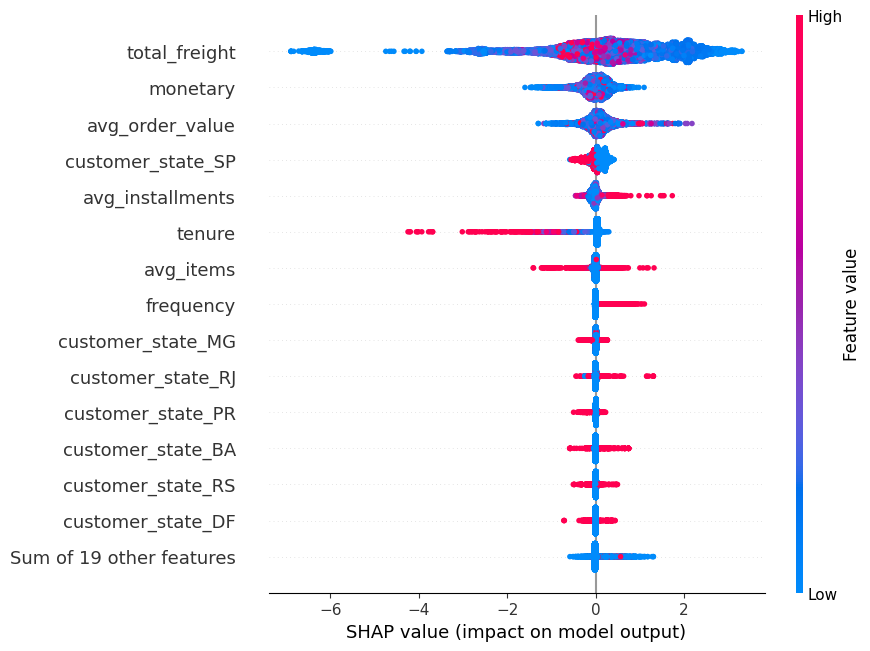

In [70]:
shap.plots.beeswarm(shap_values, max_display=15)

## 12. Mean Absolute SHAP Feature Importance

The bar plot ranks features according to their average absolute SHAP value.

Unlike traditional feature importance methods, SHAP importance reflects the true contribution of each feature toward model predictions.

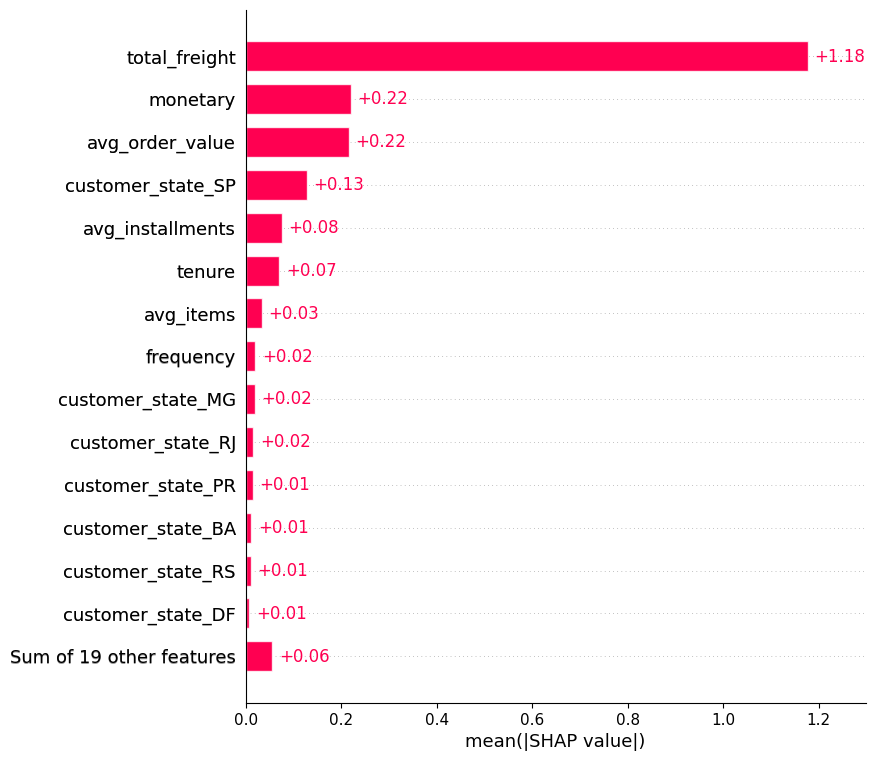

In [71]:
shap.plots.bar(shap_values, max_display=15)

### Observation

The bar chart highlights the most influential features across all customers.

Higher mean SHAP values indicate features that consistently contribute more to predicting customer churn.

In [79]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

mean_abs_shap.head(10)

,feature,mean_abs_shap
2,total_freight,1.177816
5,monetary,0.219911
0,avg_order_value,0.216429
31,customer_state_SP,0.127850
3,avg_installments,0.075585
6,tenure,0.070968
1,avg_items,0.034584
4,frequency,0.020728
16,customer_state_MG,0.018726
24,customer_state_RJ,0.016263


In [80]:
X_test[['total_freight', 'frequency', 'monetary']].corr()

,total_freight,frequency,monetary
total_freight,1.000000,0.225861,0.530953
frequency,0.225861,1.000000,0.112302
monetary,0.530953,0.112302,1.000000


## 13. Local Explanation for a Single Customer

While global explanations summarize the model's behavior across the dataset, local explanations focus on one customer.

The waterfall plot shows how individual features contribute to the final churn prediction for a selected customer.

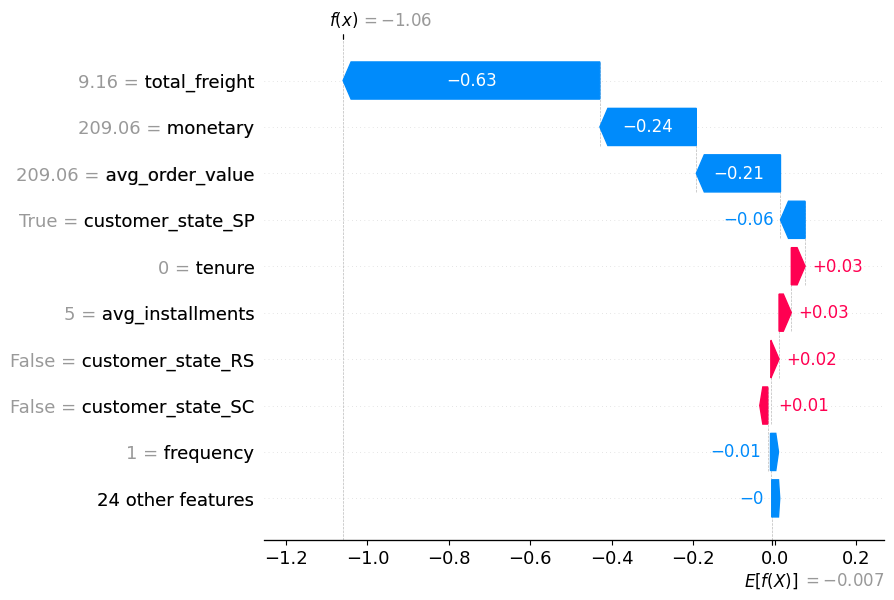

In [72]:
customer_index = 0

shap.plots.waterfall(shap_values[customer_index])

### Observation

The waterfall plot explains how each feature pushes the prediction toward either churn or non-churn for an individual customer.

Features increasing churn probability appear on one side, while features reducing churn probability appear on the opposite side.